
# Introduction:

 **Tester une solution de recommandation d’articles et de livres à des particuliers.**
 
 Comme on ne dispose pas à ce jour de données utilisateurs, on va utiliser des données disponibles en ligne pour développer notre MVP .

Ces données représentent les interactions des utilisateurs avec les articles disponibles,elles contiennent:
* Des informations sur les articles (par exemple le nombre de mots dans l’article)
* Des informations sur les sessions des utilisateurs (par exemple heures de début et de fin)
* Les interactions des utilisateurs avec les articles (sur quel article l’utilisateur a-t-il cliqué lors de sa session ?).



In [1]:
  #Import
import numpy as np 
import pandas as pd
import os
import missingno
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import pickle
from sklearn.metrics.pairwise import cosine_similarity
import pickle
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# I. Exploration de dataset

## I.1. Contenu de dataset

In [2]:

for filename in os.listdir('../input/news-portal-user-interactions-by-globocom'):
    print(os.path.join( filename))

articles_metadata.csv
articles_embeddings.pickle
clicks
clicks_sample.csv


Le dataset comprend trois fichiers principaux :

* **articles_metadata.csv**:Fichier CSV contenant des informations sur les articles publiés.

* **articles_embeddings.pickl**e: Fichier Pickle (Python 3) contenant des vecteurs d'embedding (250 dimensions) pour les articles, générés à partir du contenu des articles.
 
* **clicks** : Contient des fichiers CSV (un par heure) avec les interactions des utilisateurs (clics) sur le portail d’actualités.

* **clicks_sample.csv** : est une version allégée et prête à l’emploi d’un sous-ensemble des fichiers de clics horaires.

  

## I.2. Le fichier articles_metadata.csv

In [3]:
path_articles ="../input/news-portal-user-interactions-by-globocom/articles_metadata.csv"
articles_df = pd.read_csv(path_articles)
articles_df.head(5)

,article_id,category_id,created_at_ts,publisher_id,words_count
0,0,0,1513144419000,0,168
1,1,1,1405341936000,0,189
2,2,1,1408667706000,0,250
3,3,1,1408468313000,0,230
4,4,1,1407071171000,0,162


In [4]:
articles_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364047 entries, 0 to 364046
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   article_id     364047 non-null  int64
 1   category_id    364047 non-null  int64
 2   created_at_ts  364047 non-null  int64
 3   publisher_id   364047 non-null  int64
 4   words_count    364047 non-null  int64
dtypes: int64(5)
memory usage: 13.9 MB


In [5]:
print("Min",articles_df['created_at_ts'].apply(lambda x: pd.Timestamp(x, unit='ms')).min())
print("Max",articles_df['created_at_ts'].apply(lambda x: pd.Timestamp(x, unit='ms')).max())

Min 2006-09-27 11:14:35
Max 2018-03-13 12:12:30


In [6]:
#Nombre total d'articles
print(f"Nombre d'articles uniques: {articles_df['article_id'].nunique()}")


Nombre d'articles uniques: 364047


<Axes: >

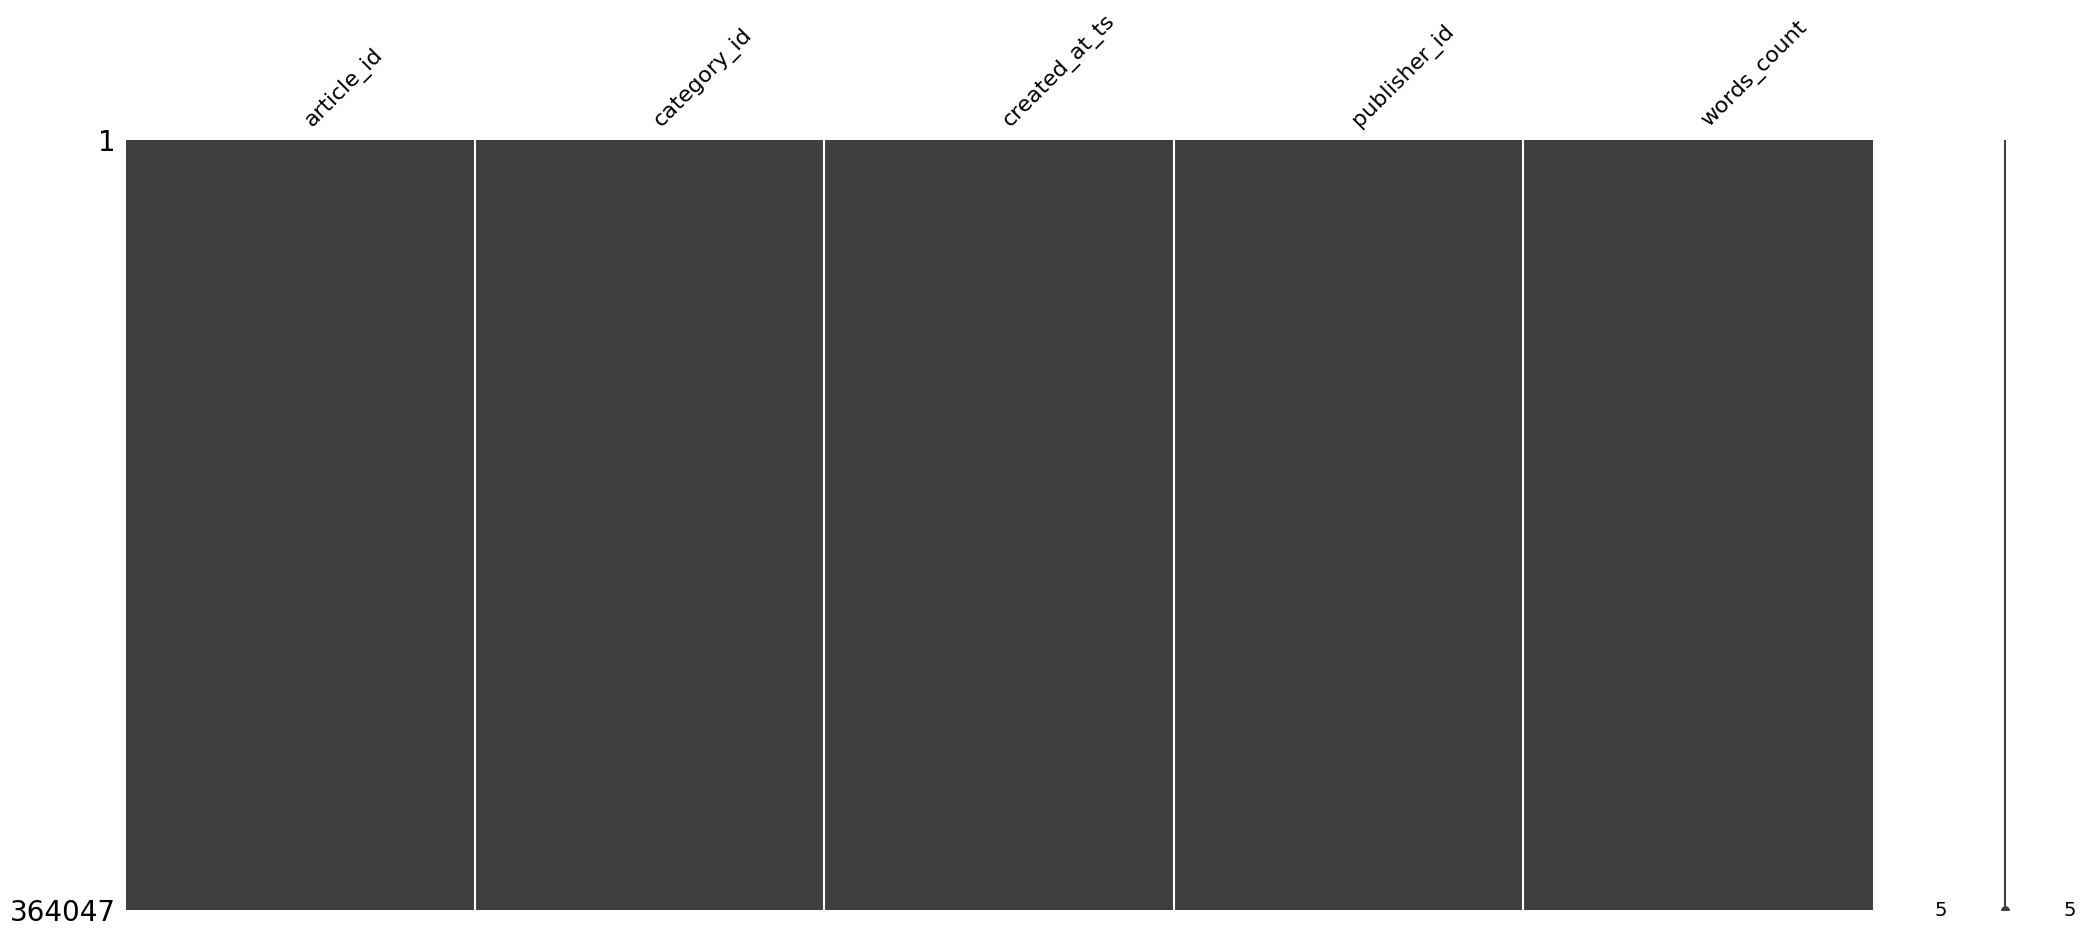

In [7]:
#Valeurs nulles
missingno.matrix(articles_df)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


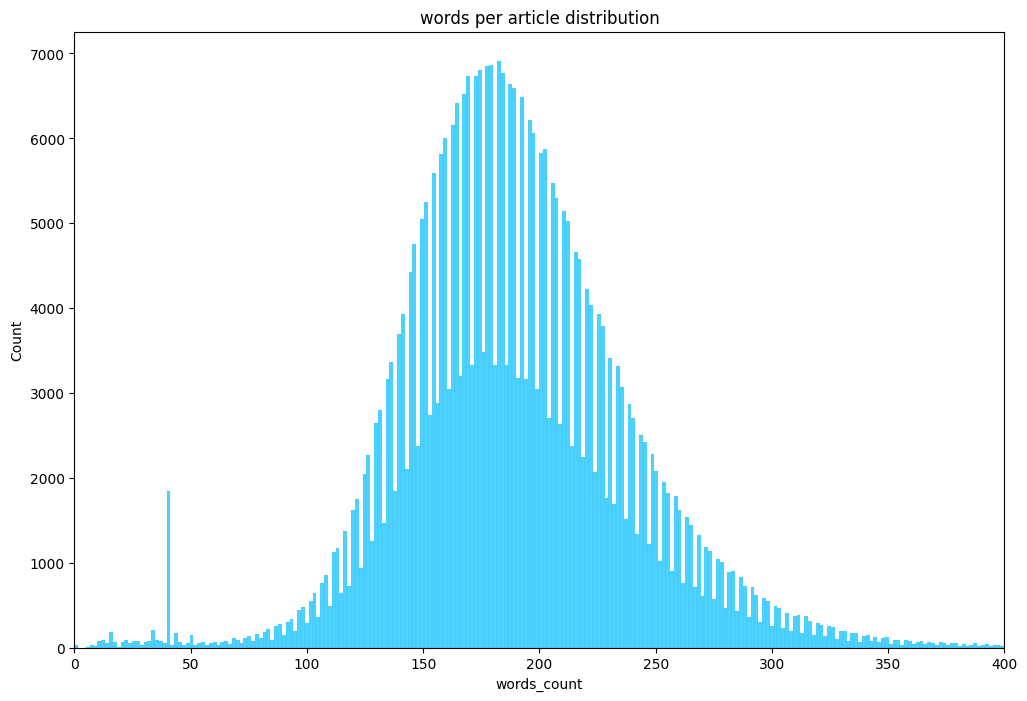

In [8]:
fig, ax = plt.subplots(figsize=(12, 8))

sns.histplot(articles_df['words_count'],
            color="deepskyblue",
            edgecolor="black",
            alpha=0.7,
            ax=ax)

plt.xlim([0,400])
plt.title('words per article distribution');
plt.show()

## I.3. Le fichier clicks_sample.csv

In [9]:
path_clicks ="../input/news-portal-user-interactions-by-globocom/clicks_sample.csv"
clicks_df = pd.read_csv(path_clicks)
clicks_df.head(5)

,user_id,session_id,session_start,session_size,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type
0,0,1506825423271737,1506825423000,2,157541,1506826828020,4,3,20,1,20,2
1,0,1506825423271737,1506825423000,2,68866,1506826858020,4,3,20,1,20,2
2,1,1506825426267738,1506825426000,2,235840,1506827017951,4,1,17,1,16,2
3,1,1506825426267738,1506825426000,2,96663,1506827047951,4,1,17,1,16,2
4,2,1506825435299739,1506825435000,2,119592,1506827090575,4,1,17,1,24,2


In [10]:
#liste des colennes
clicks_df.columns

Index(['user_id', 'session_id', 'session_start', 'session_size',
       'click_article_id', 'click_timestamp', 'click_environment',
       'click_deviceGroup', 'click_os', 'click_country', 'click_region',
       'click_referrer_type'],
      dtype='object')

In [11]:
clicks_df.shape

(1883, 12)

In [12]:
clicks_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1883 entries, 0 to 1882
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   user_id              1883 non-null   int64
 1   session_id           1883 non-null   int64
 2   session_start        1883 non-null   int64
 3   session_size         1883 non-null   int64
 4   click_article_id     1883 non-null   int64
 5   click_timestamp      1883 non-null   int64
 6   click_environment    1883 non-null   int64
 7   click_deviceGroup    1883 non-null   int64
 8   click_os             1883 non-null   int64
 9   click_country        1883 non-null   int64
 10  click_region         1883 non-null   int64
 11  click_referrer_type  1883 non-null   int64
dtypes: int64(12)
memory usage: 176.7 KB


In [13]:
#Nombre total d'utilisateurs uniques
print(f"Nombre d'utilisateurs uniques: {clicks_df['user_id'].nunique()}")

Nombre d'utilisateurs uniques: 707


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


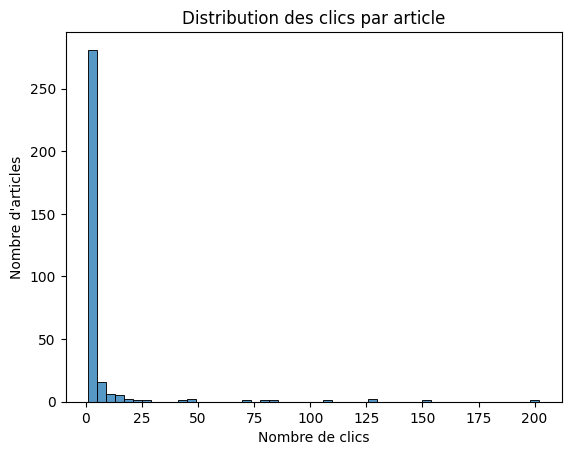

In [14]:
#Distribution des clics par article

clicks_per_article = clicks_df['click_article_id'].value_counts()
sns.histplot(clicks_per_article, bins=50)
plt.title('Distribution des clics par article')
plt.xlabel('Nombre de clics')
plt.ylabel('Nombre d\'articles')
plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


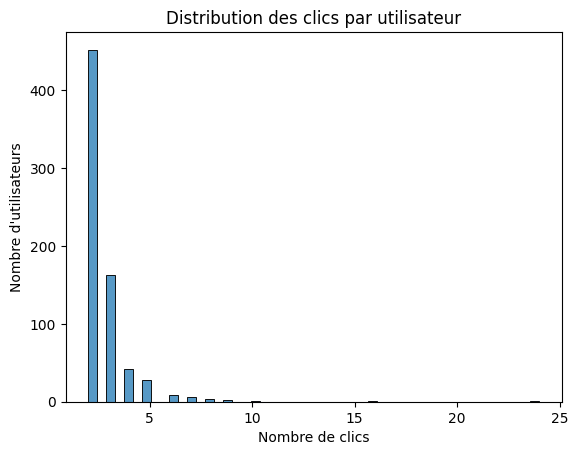

In [15]:
#Distribution des clics par utilisateur

clicks_per_user = clicks_df['user_id'].value_counts()
sns.histplot(clicks_per_user, bins=50)
plt.title('Distribution des clics par utilisateur')
plt.xlabel('Nombre de clics')
plt.ylabel('Nombre d\'utilisateurs')
plt.show()


In [16]:
# Comptage des valeurs manquantes par colonne
print(clicks_df.isnull().sum())


user_id                0
session_id             0
session_start          0
session_size           0
click_article_id       0
click_timestamp        0
click_environment      0
click_deviceGroup      0
click_os               0
click_country          0
click_region           0
click_referrer_type    0
dtype: int64


<Axes: >

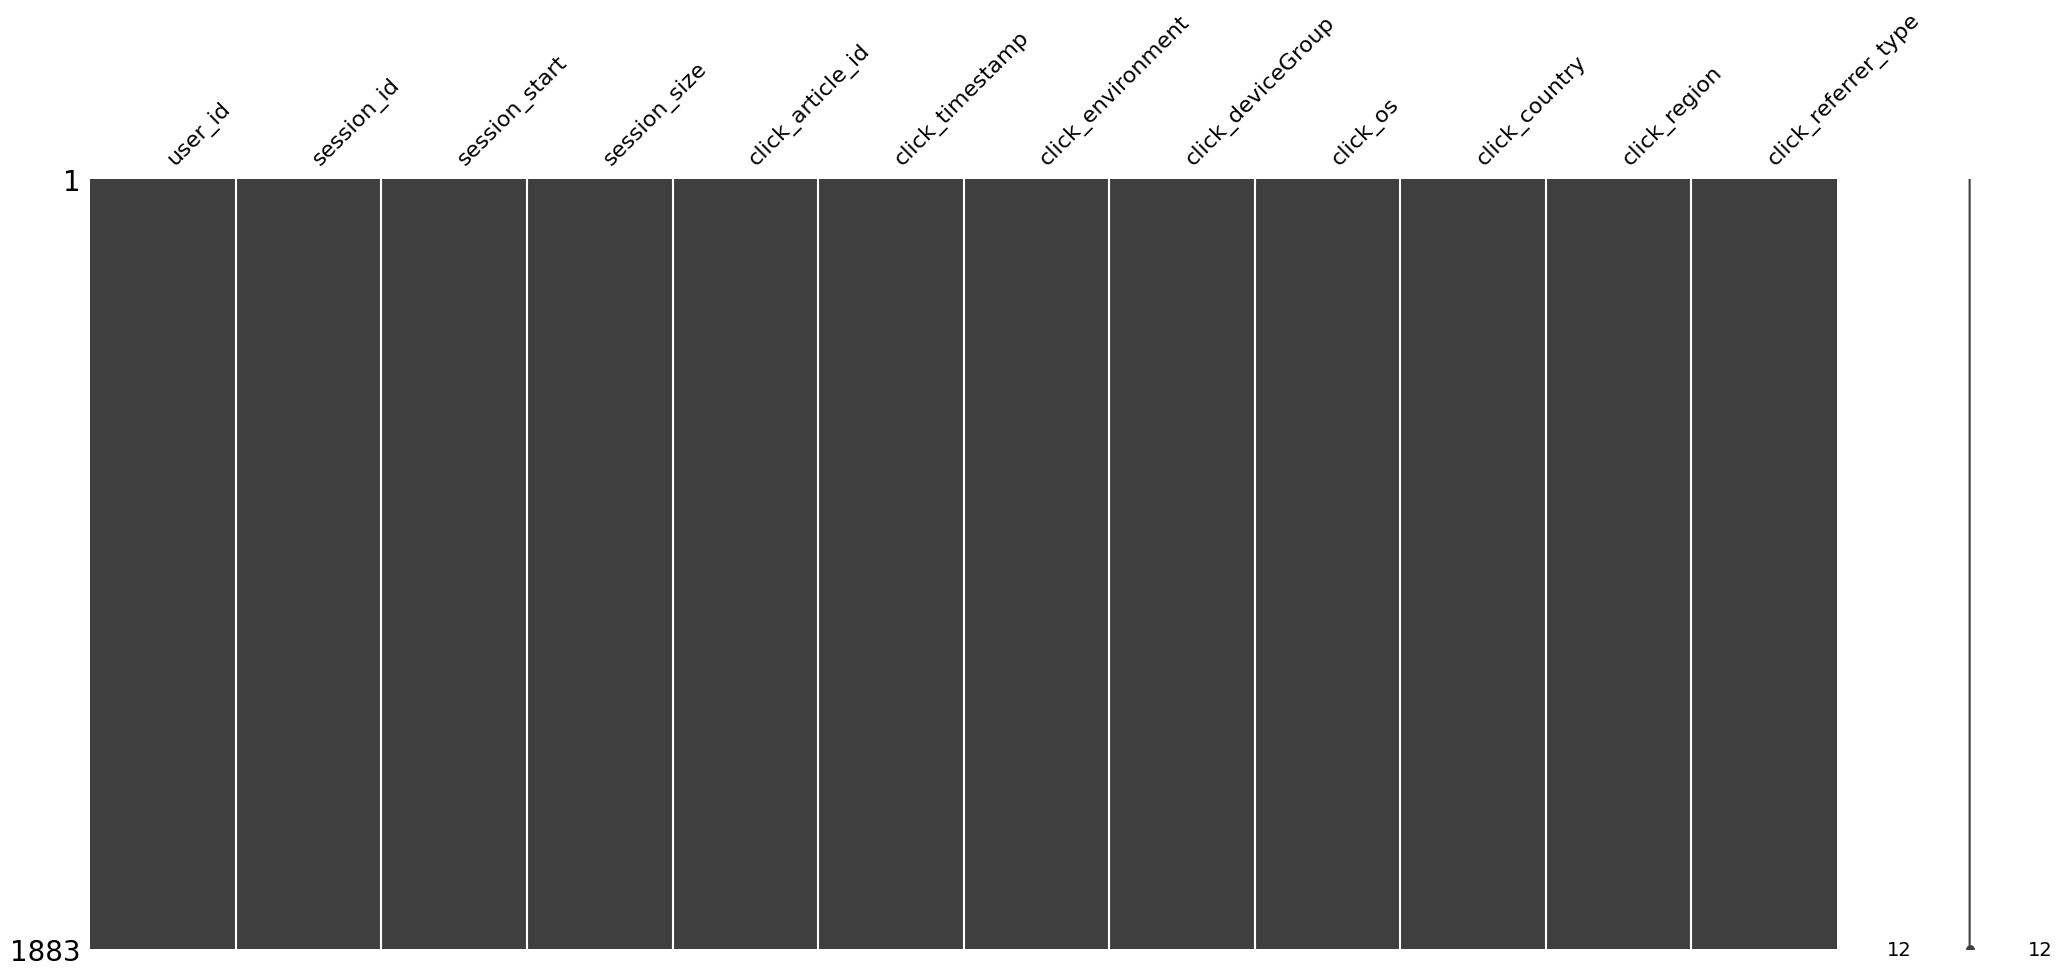

In [17]:
#Valeurs nulles
missingno.matrix(clicks_df)

In [18]:
# Vérifier les doublons exacts (mêmes user_id, article_id, timestamp)
nb_duplicates = clicks_df.duplicated().sum()
print(f"Nombre de lignes dupliquées : {nb_duplicates}")

# Supprimer les doublons si nécessaire
#clicks_df = clicks_df.drop_duplicates()


Nombre de lignes dupliquées : 0


## I.4. Le fichier articles_embeddings.pickle

In [19]:

 path_embedding = '../input/news-portal-user-interactions-by-globocom/articles_embeddings.pickle'
# Charger le fichier pickle
with open(path_embedding, "rb") as f:
    embeddings = pickle.load(f)
 
# Vérifie le type global
print("Type de embeddings :", type(embeddings))

# Si c'est un dict (le cas le plus courant)
if isinstance(embeddings, dict):
    print("Nombre d'articles :", len(embeddings))
    first_key = next(iter(embeddings))
    print("Exemple d'ID d'article :", first_key)
    print("Embedding de cet article (shape) :", embeddings[first_key].shape)

# Si c'est un array numpy
elif isinstance(embeddings, list) or hasattr(embeddings, 'shape'):
    print("Embedding numpy : shape =", embeddings.shape)
    print("Premier vecteur :", embeddings[0])
# Si c'est un dictionnaire
elif isinstance(embeddings, dict):
    print("✅ Format : dict")
    print("Nombre d'articles :", len(embeddings))
    first_key = next(iter(embeddings))
    print("Exemple de clé :", first_key)
    print("Dimension du vecteur :", embeddings[first_key].shape)

# Si c'est une liste
elif isinstance(embeddings, list):
    print("✅ Format : list")
    print("Nombre d'éléments :", len(embeddings))
    print("Extrait du premier vecteur :", embeddings[0][:1])

Type de embeddings : <class 'numpy.ndarray'>
Embedding numpy : shape = (364047, 250)
Premier vecteur : [-0.16118301 -0.95723313 -0.13794445  0.05085534  0.83005524  0.90136534
 -0.33514765 -0.55956066 -0.50060284  0.16518293  0.4284342   0.3550556
  0.87443674 -0.52888286  0.6254872   0.2689198  -0.8228351  -0.703853
 -0.62584543 -0.15285493 -0.6662412   0.04329487  0.1786375   0.04689008
  0.5945311  -0.18334764  0.19510683 -0.46763963 -0.30480695  0.35317516
  0.27818817  0.5386231  -0.37120935  0.48989806 -0.10383289  0.11917368
  0.13243659 -0.62108386 -0.45331132  0.34662652 -0.06174106 -0.7305939
 -0.38411567 -0.94075835  0.06134219  0.4825816   0.28968322 -0.62269634
 -0.05000444  0.42151213 -0.24257636  0.6687105  -0.509004   -0.46179956
  0.04390178  0.28848746  0.4498246  -0.28486234  0.916729    0.70312876
  0.85167396 -0.6272441   0.35773164  0.3901894   0.65293527  0.1036527
  0.79829276 -0.10254639 -0.2045143   0.37861153 -0.09026147 -0.2511573
  0.3259828   0.08588007 -0

In [20]:

# Vérifier le type
if isinstance(embeddings, np.ndarray):
    print("✅ Embeddings est un tableau numpy :", embeddings.shape)
    
    # Construire un mapping article_id → vecteur
    article_ids = articles_df['article_id'].tolist()
    if len(article_ids) != len(embeddings):
        raise ValueError("⚠️ Nombre d'articles différent du nombre de vecteurs !")

    article_id_to_embedding = {
        aid: embeddings[i]
        for i, aid in enumerate(article_ids)
    }

elif isinstance(embeddings, dict):
    print("✅ Embeddings est un dictionnaire (déjà mappé par article_id)")
    article_id_to_embedding = embeddings

else:
    raise TypeError("❌ Format non supporté :", type(embeddings))

# Afficher une sélection aléatoire de 5 articles et leur vecteur
sample_ids = np.random.choice(list(article_id_to_embedding.keys()), size=5, replace=False)
print("\n🧪 Extraits de vecteurs d’articles :")
for aid in sample_ids:
    print(f"Article ID {aid} → Vecteur (extrait) : {article_id_to_embedding[aid][:5]}")


✅ Embeddings est un tableau numpy : (364047, 250)

🧪 Extraits de vecteurs d’articles :
Article ID 196897 → Vecteur (extrait) : [-0.25908235 -0.9799353  -0.03863036 -0.13552402  0.8393426 ]
Article ID 353722 → Vecteur (extrait) : [ 0.29101378 -0.9751297   0.7366891   0.13723241 -0.4744679 ]
Article ID 14399 → Vecteur (extrait) : [-0.3758351  -0.96363926  0.6160606  -0.29540783  0.30175307]
Article ID 113375 → Vecteur (extrait) : [-0.88684905 -0.97168     0.41023433 -0.57956564 -0.01628173]
Article ID 284073 → Vecteur (extrait) : [ 0.33333147 -0.97279406 -0.5218135  -0.6448836  -0.8709106 ]


# II. Préparation des données et feature engineering

## II.1. Fusion de clicks_sample.csv et articles_metadata.csv
La fusion des dataframes articles et clicks contiendra tous les clics enrichis par les infos des articles.



In [21]:
# Fusionner sur l’ID d’article
merged_df = clicks_df.merge(articles_df, how='left',
                            left_on='click_article_id', 
                            right_on='article_id')

#Aperçu du résultat
print(merged_df.head())
print(merged_df.info())

#Vérification des valeurs manquantes après fusion
print(merged_df.isnull().sum())


   user_id        session_id  session_start  session_size  click_article_id  \
0        0  1506825423271737  1506825423000             2            157541   
1        0  1506825423271737  1506825423000             2             68866   
2        1  1506825426267738  1506825426000             2            235840   
3        1  1506825426267738  1506825426000             2             96663   
4        2  1506825435299739  1506825435000             2            119592   

   click_timestamp  click_environment  click_deviceGroup  click_os  \
0    1506826828020                  4                  3        20   
1    1506826858020                  4                  3        20   
2    1506827017951                  4                  1        17   
3    1506827047951                  4                  1        17   
4    1506827090575                  4                  1        17   

   click_country  click_region  click_referrer_type  article_id  category_id  \
0              1        

**Objectif global:**
Dans le but de prédire une interaction utilisateur × article,on va construire un dataset enrichi avec:

* Informations sur l'utilisateur (comportement navigation/session)

* Informations sur l'article (caractéristiques du contenu)

* Information sur l'interaction (temps, device, localisation)


**Plan de feature engineering :**

* Encodage catégoriel (category_id, publisher_id)

* Standardisation (words_count)

* Création de nouvelles features (temps écoulé entre click_timestamp et created_at_ts, etc.)




## II.2. Plan de Feature Engineering


### a.Création de features utilisateurs (user_id)

**Features**:

* **session_size**:Nombre de clics dans la session

* **click_environment**:Environnement du clic (ex: mobile, desktop)

* **click_deviceGroup**:Type de device utilisé (mobile, tablet, etc.)

* **click_os**:Système d'exploitation utilisé

* **click_country,click_regio:** Localisation du clic

* **click_referrer_type**	: D'où vient l'utilisateur(direct, recherche,réseaux,sociaux...)

**Encoding :**
One-Hot Encode pour click_deviceGroup, click_os, click_country, click_environment, etc.

### b. Création de features temporelles
À partir de click_timestamp et session_start :

* **hour**:Heure du clic (extraction depuis timestamp)
 
* **day_of_week:** Jour de la semaine du clic

* **time_since_session_start:**	Différence entre click_timestamp et session_start

### c. Création de features articles
Depuis articles_df :

Feature	Description
category_id	Catégorie de l'article (One-Hot ou Label Encoding)
publisher_id	Identifiant de l'éditeur (One-Hot ou Label Encoding)
words_count	Longueur de l'article
 
 Standardiser words_count (normalisation min-max ou z-score)



### d. (Optionnel) Features d'interaction utilisateur-article
Des features croisées :

Feature	Description
user_pref_category	Catégorie la plus lue par l’utilisateur
user_avg_words_count	Nombre moyen de mots des articles cliqués par l'utilisateur
user_top_referrer	Referrer préféré de l'utilisateur

**Comment faire ?**

GroupBy user_id → statistiques sur ses clics précédents

Joindre ensuite ces features sur user_id


In [22]:
  # Création de features temporelles
merged_df['click_datetime'] = pd.to_datetime(merged_df['click_timestamp'], unit='ms')
merged_df['click_hour'] = merged_df['click_datetime'].dt.hour
merged_df['click_dayofweek'] = merged_df['click_datetime'].dt.dayofweek
merged_df['time_since_session_start'] = (merged_df['click_timestamp'] - merged_df['session_start']) / 1000  # en secondes

# Sélection des colonnes utiles
features = merged_df[[
    'click_environment', 'click_deviceGroup', 'click_os',
    'click_country', 'click_referrer_type', 'click_hour', 'click_dayofweek',
    'time_since_session_start', 'session_size', 'category_id', 'publisher_id', 'words_count'
]].copy()

# Remplir les valeurs manquantes si besoin
features.fillna(-1, inplace=True)

# Définition des colonnes catégorielles et numériques
categorical_cols = ['click_environment', 'click_deviceGroup', 'click_os', 'click_country', 'click_referrer_type', 'category_id', 'publisher_id']
numerical_cols = ['click_hour', 'click_dayofweek', 'time_since_session_start', 'session_size', 'words_count']

# Préprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numerical_cols)
])

# Application du pipeline
X_processed = preprocessor.fit_transform(features)

# Dataset final prêt pour entraînement
# (y = clic réel, ici = 1 pour tous car ce sont des clics réels. À compléter avec des négatifs pour ranking)
y = pd.Series([1] * len(features), name='label')

# Affichage
print("Dataset prêt pour modélisation :")
print("Shape des features:", X_processed.shape)
print("Shape des labels:", y.shape)


Dataset prêt pour modélisation :
Shape des features: (1883, 116)
Shape des labels: (1883,)


# III. Modélisation 

## III.1. **La recommandation par filtrage collaboratif(collaborative Filtering)**

C'est l'une des techniques les plus populaires pour les systèmes de recommandation .

L'idée : recommander des articles à un utilisateur en se basant sur les comportements des autres utilisateurs similaires.

Deux grandes approches :

* **User-based** : recommander ce que des utilisateurs similaires ont aimé.
* **Item-based** : recommander des articles similaires à ceux que l’utilisateur a consultés.

**Le filtrage collaboratif**, en particulier avec la librairie surprise, ne nécessite que trois colonnes :

* user_id

* item_id (ici click_article_id)

* rating (ou score implicite, souvent 1 pour un clic)

Il n’utilise pas d’informations sur le contenu des articles (comme le titre, la catégorie, etc.).

**Modélisation ALS**

**La modélisation ALS** (Alternating Least Squares) est une technique de factorisation de matrices largement utilisée dans les systèmes de recommandation. 

Son objectif est de prédire la préférence d’un utilisateur pour des articles qu’il n’a pas encore consultés, en exploitant les interactions passées entre utilisateurs et articles (par exemple, les clics).

**La méthode** « Alternating » fait référence à l’optimisation alternée de ces deux matrices :

* Dans un premier temps, on fixe la matrice article et on ajuste la matrice utilisateur en minimisant l’erreur quadratique (Least Squares).

* Dans un second temps, on fixe la matrice utilisateur et on ajuste la matrice article.

* Ce processus est répété en alternance jusqu’à la convergence.

In [23]:
# PARTIE 1 - ALS
from scipy.sparse import csr_matrix
from implicit.als import AlternatingLeastSquares
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# === . Séparation Train/Test ===
train_df, test_df = train_test_split(clicks_df, test_size=0.2, random_state=42)



# 1. Construction de la matrice utilisateur-article
user_item_matrix_train = train_df.pivot_table(
    index='user_id',
    columns='click_article_id',
    aggfunc='size',
    fill_value=0
)
user_item_sparse_train = csr_matrix(user_item_matrix_train.values)

# 2. Entraînement du modèle ALS
als_model = AlternatingLeastSquares(
    factors=20,
    regularization=0.1,
    iterations=15,
    use_gpu=False
)
als_model.fit(user_item_sparse_train)

# 3. Fonctions de mapping

def fallback_recommendations(train_df, n=10):
    return train_df['click_article_id'].value_counts().head(n).index.tolist()

user_mapping = {user_id: idx for idx, user_id in enumerate(user_item_matrix_train.index)}
item_id_mapping = {idx: item_id for idx, item_id in enumerate(user_item_matrix_train.columns)}

# 4. Fonction de recommandation
def als_reco(user_id):
    user_index = user_mapping.get(user_id)
    if user_index is None:
        return fallback_recommendations(train_df, n=10)
    item_ids, _ = als_model.recommend(user_index, user_item_sparse_train[user_index], N=10)
    return [item_id_mapping[idx] for idx in item_ids]

# 5. Évaluation  des performances (avec logs d’overlap) ===
def evaluate_performance_at_k(recommend_func, user_ids, ground_truth, top_n=10, log_overlap=True):
    precisions = []
    recalls = []

    for user_id in tqdm(user_ids, desc=f"Évaluation (top {top_n})"):
        true_articles = set(ground_truth[ground_truth['user_id'] == user_id]['click_article_id'])
        recommended_articles = recommend_func(user_id)

        if not true_articles:
            continue

        hits = sum([1 for article in recommended_articles if article in true_articles])

        precision = hits / top_n
        recall = hits / len(true_articles) if len(true_articles) > 0 else 0

        precisions.append(precision)
        recalls.append(recall)

        if log_overlap and hits > 0:
            print(f"User {user_id} - Test articles: {true_articles} - Recommended: {recommended_articles} - Hits: {hits}")

    avg_precision = np.mean(precisions) if precisions else 0
    avg_recall = np.mean(recalls) if recalls else 0
    f1 = (2 * avg_precision * avg_recall) / (avg_precision + avg_recall) if (avg_precision + avg_recall) > 0 else 0

    return avg_precision, avg_recall, f1

# === . Évaluation des modèles ===
user_ids_test = test_df['user_id'].unique()

precision_als, recall_als, f1_als = evaluate_performance_at_k(als_reco, user_ids_test, test_df)

print("\n== Résultats ALS ==")
print(f"Précision ALS: {precision_als:.2f}")
print(f"Rappel ALS: {recall_als:.2f}")
print(f"F1-score ALS: {f1_als:.2f}")


ModuleNotFoundError: No module named 'implicit'

## III.2. La recommandation par la recherche de similarité

**La recommandation par similarité** consiste à :

* Représenter chaque article (ou utilisateur) comme un vecteur numérique (embedding)
    
*  Calculer la similarité cosinus entre articles (vecteurs).

*  Recommander aux utilisateurs des articles similaires à ceux déjà consultés

*  Basé sur les profils d’utilisateurs ou les embeddings d’articles

**Étapes :**

* Se disposer d'un dictionnaire article_id → embedding (ex. via articles_embeddings.pickle)

* Calculer la similarité cosinus entre un vecteur (profil utilisateur ou article) et tous les autres 

* Retourner les articles avec la meilleure similarité



In [ ]:
# PARTIE 3 - SIMILARITÉ D’ARTICLE
item_user_matrix_train = user_item_sparse_train.T
item_similarity = cosine_similarity(item_user_matrix_train)

item_idx_mapping = {item_id: idx for idx, item_id in enumerate(user_item_matrix_train.columns)}
reverse_item_idx_mapping = {idx: item_id for item_id, idx in item_idx_mapping.items()}

# 1. Fonctio n de recommandation
def item_similarity_reco(user_id):
    clicked_ids = train_df[train_df['user_id'] == user_id]['click_article_id']
    rec_scores = np.zeros(item_similarity.shape[0])

    for aid in clicked_ids:
        idx = item_idx_mapping.get(aid)
        if idx is not None:
            rec_scores += item_similarity[idx]

    seen_idxs = [item_idx_mapping[aid] for aid in clicked_ids if aid in item_idx_mapping]
    rec_scores[seen_idxs] = -1

    top_idxs = np.argsort(rec_scores)[-10:][::-1]
    recommended_items = [reverse_item_idx_mapping[idx] for idx in top_idxs]
    return recommended_items if recommended_items else fallback_recommendations(train_df, n=10)

# 2. Évaluation
precision_item, recall_item, f1_item = evaluate_performance_at_k(item_similarity_reco, user_ids_test, test_df)

print("\n== Résultats Similarité d’article ==")
print(f"Précision Similarité d’article: {precision_item:.2f}")
print(f"Rappel Similarité d’article: {recall_item:.2f}")
print(f"F1-score Similarité d’article: {f1_item:.2f}")


## III.3. La recommandation par génération d'embeddings

La recommandation par génération d'embeddings est une approche basée sur le contenu, où :

* Chaque article est représenté par un vecteur d'embedding (souvent généré à partir de son titre, texte, tags…)

* Un profil utilisateur est créé en combinant les embeddings des articles qu’il a lus

* On recommande les articles dont l’embedding est le plus proche de celui du profil utilisateur (via similarité cosinus)

In [ ]:
# PARTIE 2 - EMBEDDINGS NUMPY
embeddings = np.load(path_embedding , allow_pickle=True)

# 1. Mapping
article_ids = articles_df['article_id'].tolist()
article_id_to_index = {aid: idx for idx, aid in enumerate(article_ids)}
index_to_article_id = {idx: aid for idx, aid in enumerate(article_ids)}



# 2. Profil utilisateur
def build_user_profile(user_id, clicks, article_id_to_index, embeddings):
    clicked_ids = clicks[clicks['user_id'] == user_id]['click_article_id']
    indices = [article_id_to_index[aid] for aid in clicked_ids if aid in article_id_to_index]
    if not indices:
        return None
    profile = np.mean(embeddings[indices], axis=0)
    return profile
 
# 3. Fonction de recommandation

test_articles = set(test_df['click_article_id'])

def embedding_reco(user_id):
    profile = build_user_profile(user_id, train_df, article_id_to_index, embeddings)
    if profile is None:
        return fallback_recommendations(train_df, n=10)
    similarities = cosine_similarity(profile.reshape(1, -1), embeddings)[0]
    recommended = sorted(
        [(index_to_article_id[idx], sim) for idx, sim in enumerate(similarities)
         if index_to_article_id[idx] in test_articles],
        key=lambda x: x[1], reverse=True
    )
    return [aid for aid, _ in recommended[:10]] if recommended else fallback_recommendations(train_df, n=10)

# 4. Évaluation
precision_embed, recall_embed, f1_embed = evaluate_performance_at_k(embedding_reco, user_ids_test, test_df)

print("\n== Résultats Embeddings NumPy ==")
print(f"Précision Embeddings: {precision_embed:.2f}")
print(f"Rappel Embeddings: {recall_embed:.2f}")
print(f"F1-score Embeddings: {f1_embed:.2f}")


## III.4. Evaluation

Pour évaluer un système de recommandation, tu dois adapter les méthodes d’évaluation au type de recommandation : classement d’articles, clics, précision, etc. 

In [ ]:
results = pd.DataFrame({
    'Modèle': ['ALS', 'Embeddings NumPy', 'Similarité d’article'],
    'Précision@10': [round(precision_als, 2), round(precision_embed, 2), round(precision_item, 2)],
    'Rappel@10': [round(recall_als, 2), round(recall_embed, 2), round(recall_item, 2)],
    'F1-Score': [round(f1_als, 2), round(f1_embed, 2), round(f1_item, 2)]
})

print("\n=== Résultats comparatifs ===")
print(results)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Données
data = {
    'Modèle': ['ALS', 'Embeddings NumPy', 'Similarité d’article'],
    'Précision@10': [0.02, 0.03, 0.04],
    'Rappel@10': [0.11, 0.21, 0.34],
    'F1-Score': [0.03, 0.06, 0.07]
}

df = pd.DataFrame(data)

# Paramètres du graphique
bar_width = 0.2
x = np.arange(len(df['Modèle']))

# Création du diagramme
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x - bar_width, df['Précision@10'], width=bar_width, label='Précision@10')
ax.bar(x, df['Rappel@10'], width=bar_width, label='Rappel@10')
ax.bar(x + bar_width, df['F1-Score'], width=bar_width, label='F1-Score')

# Personnalisation
ax.set_xlabel('Modèle')
ax.set_ylabel('Score')
ax.set_title('Comparaison des modèles de recommandation')
ax.set_xticks(x)
ax.set_xticklabels(df['Modèle'])
ax.legend()

# Affichage
plt.ylim(0, 0.4)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


**Conclusion des Résultats Comparatifs**

L’analyse des performances des trois modèles testés montre des différences marquées dans leur capacité à recommander des articles pertinents pour les utilisateurs :

**Similarité d’article**: est le modèle qui obtient les meilleurs résultats globaux sur l’ensemble des métriques, avec un rappel élevé (0.34) et un F1-score supérieur (0.07). Cela s’explique notamment par la simplicité et l’efficacité de la méthode pour capturer la proximité sémantique entre les articles cliqués par l’utilisateur.

**Embeddings NumPy** : affiche un rappel satisfaisant (0.21), bien qu’il reste en retrait par rapport à la Similarité d’article. Cela montre une certaine capacité du modèle à recommander des articles pertinents grâce à la représentation vectorielle des contenus, mais aussi une marge d’amélioration en termes de précision (0.03).

**ALS**: reste en retrait sur l’ensemble des métriques, avec une précision et un rappel modestes (0.02 et 0.11 respectivement). Cela suggère que le modèle souffre probablement d’un dataset trop petit ou trop dispersé pour capter correctement les interactions utilisateur-article, limitant sa capacité à généraliser efficacement.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

# 1️⃣ Fonction d’évaluation des performances
def evaluate_performance_at_k(recommend_func, user_ids, ground_truth, top_n=10, log_overlap=False):
    precisions = []
    recalls = []

    for user_id in tqdm(user_ids, desc=f"Évaluation (top {top_n})"):
        true_articles = set(ground_truth[ground_truth['user_id'] == user_id]['click_article_id'])
        recommended_articles = recommend_func(user_id)

        if not true_articles:
            continue

        hits = sum([1 for article in recommended_articles if article in true_articles])

        precision = hits / top_n
        recall = hits / len(true_articles) if len(true_articles) > 0 else 0

        precisions.append(precision)
        recalls.append(recall)

        if log_overlap and hits > 0:
            print(f"User {user_id} - Hits: {hits} - Recommended: {recommended_articles} - True: {true_articles}")

    avg_precision = np.mean(precisions) if precisions else 0
    avg_recall = np.mean(recalls) if recalls else 0
    f1 = (2 * avg_precision * avg_recall) / (avg_precision + avg_recall) if (avg_precision + avg_recall) > 0 else 0

    return avg_precision, avg_recall, f1

# 2️⃣ Fonction fallback (popular articles)
def fallback_recommendations(train_df, n=10):
    return train_df['click_article_id'].value_counts().head(n).index.tolist()

# 3️⃣ Fonction de mapping articles et utilisateurs
def create_mappings(articles_df, train_df):
    article_ids = articles_df['article_id'].tolist()
    article_id_to_index = {aid: idx for idx, aid in enumerate(article_ids)}
    index_to_article_id = {idx: aid for idx, aid in enumerate(article_ids)}

    user_ids = train_df['user_id'].unique()
    user_id_to_index = {uid: idx for idx, uid in enumerate(user_ids)}
    index_to_user_id = {idx: uid for idx, uid in enumerate(user_ids)}

    return article_id_to_index, index_to_article_id, user_id_to_index, index_to_user_id

# 4️⃣ Fonction de tableau récapitulatif
def build_results_dataframe(models, precisions, recalls, f1_scores):
    results = pd.DataFrame({
        'Modèle': models,
        'Précision@10': [round(p, 2) for p in precisions],
        'Rappel@10': [round(r, 2) for r in recalls],
        'F1-Score': [round(f, 2) for f in f1_scores]
    })
    return results


In [ ]:
from common import (
    evaluate_performance_at_k,
    fallback_recommendations,
    create_mappings,
    build_results_dataframe
)


In [ ]:
#pip install implicit
